This script combines the normal preprocessing and filtering of the data <br>
Takes the location of all the numpy files and makes a dataframe, which is filtered by image type <br>
Saves an all_nonsync_data.pkl

A. Edelen & F. Cropp <br>
2024-11-24


## User Input
Choose which dataset to work on

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params() # Missing data about upstream gun/solenoid --> could be useful --something to come back to
# # pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_January_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571_smoke.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import json
import glob
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import os
import yaml
plt.rcParams.update({'font.size': 14})

## Manipulate Inputs

In [5]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)

## Get all values file names

In [6]:
def second_parent(orig_path):
    parent, file = os.path.split(orig_path)
    parentparent,parentfile = os.path.split(parent)
    return parentparent

In [7]:
def fix_path(new_path,p):
    new_parent,foo = os.path.split(pathlist[i])
    old_parent = second_parent(p)
    
    return p.replace(old_parent,new_parent)

In [8]:
import h5py
def read_hdf(filename):
    with h5py.File(filename, "r") as f:
    
        a_group_key = list(f.keys())[0]
        ds_arr = f[a_group_key][()]
    return ds_arr

In [9]:
fnamelist_all_values = []
data = []
for i in range(len(pathlist)):
    # if os.path.isdir(pathlist[i]):
    fnamelist_all_values = fnamelist_all_values + ([i for i in glob.glob(pathlist[i]+'*values*.npy')])
    # else:
    #     with open(pathlist[i], 'r') as file:
    #         t = yaml.safe_load(file)
    #         d = pd.DataFrame(t['data'])
    #     names =[]
    #     for j,v in d.iterrows():
    #         names.append(fix_path(pathlist[i],v['save_filename']))
    #     d['save_filename'] = names
    #     data.append(d)
# data = pd.concat(data)
fnamelist_all_values = np.sort(fnamelist_all_values)

In [10]:
# data = pd.concat(data)

In [11]:
# data['save_filename'].iloc[0]

In [12]:
# dlist = []
# import datetime
# for i,v in data.iterrows():
#     t = v['save_filename'].split('_')[-1]
#     t = t.split('.h5')[0]
#     date_time = datetime.datetime.fromtimestamp(int(t))
#     dlist.append(date_time)

In [13]:
# sorted(dlist)

In [14]:
# parent, file = os.path.split(data['save_filename'].iloc[0])

# parentparent,parentfile = os.path.split(parent)

In [15]:
# parentparent

In [16]:
# data.columns
# 

In [17]:
# img_list = []
# for i,v in data.iterrows():
#     image_file =v['save_filename']
#     img = np.squeeze(read_hdf(image_file))
#     img_list.append(img)
    
    

In [18]:
# data['images'] = img_list

In [19]:
# data.columns

In [20]:
# rel_pvs = ['QUAD:IN10:121:BCTRL', 'QUAD:IN10:122:BCTRL',
#        'QUAD:IN10:361:BCTRL', 'QUAD:IN10:371:BCTRL', 'QUAD:IN10:425:BCTRL',
#        'QUAD:IN10:441:BCTRL', 'QUAD:IN10:511:BCTRL', 'QUAD:IN10:525:BCTRL',
#        'SOLN:IN10:121:BCTRL','images']

In [21]:
# data = data[rel_pvs]

In [22]:
# data

## Get all image file names 

In [23]:
fnamelist_all_imgs = []
for i in range(0, len(fnamelist_all_values)):
    imgs_name_temp = fnamelist_all_values[i][0:-36]+'imgs_'+fnamelist_all_values[i][-29:]
    fnamelist_all_imgs.append(imgs_name_temp)

## Load all the files into a single dataframe (matching)

In [24]:
def Merge(dict1, dict2):
    return(dict1.update(dict2))

In [25]:
if '2024-03-' in save_loc and screen_nickname=='241':
    charges = [1600 if 'Nominal' in val else 2800 if '2p8' in val else 200 if '200' in val else 500 if '500' in val else None for val in fnamelist_all_values]
    assert len(charges)==len(fnamelist_all_values),"Problem: charges not aligned"
    print('March 2024 241')

In [26]:
df_read = pd.DataFrame({})
for i in range(0,len(fnamelist_all_values)):
    try:
        values_ex = np.load(fnamelist_all_values[i],allow_pickle=True)
        values_dict = values_ex.item()
        
        imgs_ex = np.load(fnamelist_all_imgs[i],allow_pickle=True)
        imgs_dict = imgs_ex.item()
    
        
        
        filled = imgs_dict
        
        result = {k: filled.get(k, 'NaN') for k in empty}
    
        Merge(values_dict, result)
    
        timestamp = fnamelist_all_values[i][-29:-4]
        values_dict['timestamp']=timestamp
    
        df_read = pd.concat([df_read,pd.DataFrame.transpose(pd.DataFrame.from_dict(values_dict,orient='index'))],axis=0, ignore_index=True)
    except Exception as e:
        print(e)
df_read

,SOLN:IN10:121:BACT,SOLN:IN10:111:BACT,QUAD:IN10:121:BACT,QUAD:IN10:122:BACT,QUAD:IN10:361:BACT,QUAD:IN10:371:BACT,QUAD:IN10:425:BACT,QUAD:IN10:441:BACT,QUAD:IN10:511:BACT,QUAD:IN10:525:BACT,...,PROF:IN10:711:X,PROF:IN10:711:Y,PROF:IN10:711:RESOLUTION,timestamp,PMTR:HT10:950:PWR,IOC:SYS1:MP01:LSHUTCTL,KLYS:LI10:51:PDES,KLYS:LI10:51:AMPL,TCAV:IN20:490:TC0_C_1_TCTL,KLYS:LI20:51:BEAMCODE1_TCTL
0,0.399999,0.000009,-0.009301,0.0095,-3.223822,3.049889,-6.440656,6.712466,-2.610925,1.679063,...,NaN,NaN,NaN,2024-01-27T10:58:28-08:00,NaN,NaN,NaN,NaN,NaN,NaN
1,0.399999,0.0,-0.0093,0.0095,-3.223976,3.049712,-6.442022,6.711299,-2.610955,1.680049,...,NaN,NaN,NaN,2024-01-27T10:59:50-08:00,NaN,NaN,NaN,NaN,NaN,NaN
2,0.399999,-0.000007,-0.0093,0.0095,-3.223837,3.049997,-6.44091,6.712378,-2.610088,1.679065,...,NaN,NaN,NaN,2024-01-27T11:01:03-08:00,NaN,NaN,NaN,NaN,NaN,NaN
3,0.399999,0.000009,-0.009295,0.0095,-3.222818,3.049917,-6.438905,6.713666,-2.609509,1.68008,...,NaN,NaN,NaN,2024-01-27T17:46:00-08:00,0.394249,0,-58.455109,0.030014,0,0
4,0.399999,0.0,-0.009295,0.0095,-3.222813,3.049915,-6.439694,6.713245,-2.610387,1.679781,...,NaN,NaN,NaN,2024-01-27T17:46:06-08:00,0.389671,0,-58.455109,0.030071,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,0.409999,0.000007,-0.009296,0.0095,-3.222892,3.049866,-6.438096,6.714497,-2.610304,4.393699,...,NaN,NaN,NaN,2024-01-27T23:29:01-08:00,0.479507,0,-58.455109,0.02962,0,0
1754,0.41,0.00001,-0.009295,0.0095,-3.222972,3.050049,-6.438485,6.712879,-2.611456,4.392827,...,NaN,NaN,NaN,2024-01-27T23:29:06-08:00,0.382805,0,-58.455109,0.030053,0,0
1755,0.409999,0.0,-0.009296,0.0095,-3.222926,3.049929,-6.438911,6.714081,-2.610494,5.000623,...,NaN,NaN,NaN,2024-01-27T23:29:13-08:00,0.423431,0,-58.455109,0.029978,0,0
1756,0.41,0.00001,-0.009296,0.0095,-3.22288,3.049952,-6.438115,6.715135,-2.610493,5.001537,...,NaN,NaN,NaN,2024-01-27T23:29:18-08:00,0.487137,0,-58.455109,0.029995,0,0


In [27]:
list(df_read.columns)

['SOLN:IN10:121:BACT',
 'SOLN:IN10:111:BACT',
 'QUAD:IN10:121:BACT',
 'QUAD:IN10:122:BACT',
 'QUAD:IN10:361:BACT',
 'QUAD:IN10:371:BACT',
 'QUAD:IN10:425:BACT',
 'QUAD:IN10:441:BACT',
 'QUAD:IN10:511:BACT',
 'QUAD:IN10:525:BACT',
 'SOLN:IN10:121:BCTRL',
 'SOLN:IN10:111:BCTRL',
 'QUAD:IN10:121:BCTRL',
 'QUAD:IN10:122:BCTRL',
 'QUAD:IN10:361:BCTRL',
 'QUAD:IN10:371:BCTRL',
 'QUAD:IN10:425:BCTRL',
 'QUAD:IN10:441:BCTRL',
 'QUAD:IN10:511:BCTRL',
 'QUAD:IN10:525:BCTRL',
 'KLYS:LI10:21:PDES',
 'KLYS:LI10:21:ADES',
 'KLYS:LI10:21:AMPL',
 'KLYS:LI10:21:PHAS',
 'KLYS:LI10:21:SFB_PDIS',
 'KLYS:LI10:31:PDES',
 'KLYS:LI10:31:ADES',
 'KLYS:LI10:31:AMPL',
 'KLYS:LI10:31:PHAS',
 'KLYS:LI10:41:PDES',
 'KLYS:LI10:41:ADES',
 'KLYS:LI10:41:AMPL',
 'KLYS:LI10:41:PHAS',
 'KLYS:LI10:51:PHAS',
 'KLYS:LI10:51:AMPL ',
 'LASR:LT10:930:PWR',
 'BPMS:IN10:221:X',
 'BPMS:IN10:371:X',
 'BPMS:IN10:425:X',
 'BPMS:IN10:511:X',
 'BPMS:IN10:525:X',
 'BPMS:IN10:581:X',
 'BPMS:IN10:631:X',
 'BPMS:IN10:651:X',
 'BPMS:IN10:7

## Filter by screen

In [28]:
pd.unique(df_read['PROF:IN10:571:RESOLUTION'])

array(['NaN', 11.1732], dtype=object)

In [29]:
df_read['CAMR:LT10:900:Image:ArrayData']

0                                                     NaN
1                                                     NaN
2       [12, 4, 9, 1, 11, 5, 5, 2, 0, 5, 0, 6, 13, 2, ...
3       [3, 8, 15, 12, 7, 3, 14, 7, 8, 0, 7, 0, 6, 3, ...
4       [9, 11, 10, 0, 3, 2, 5, 10, 4, 10, 16, 12, 5, ...
                              ...                        
1753    [11, 12, 4, 4, 9, 0, 10, 0, 6, 3, 0, 7, 7, 3, ...
1754    [10, 8, 1, 6, 9, 0, 4, 3, 6, 6, 0, 10, 2, 3, 3...
1755    [8, 6, 12, 2, 7, 3, 2, 1, 5, 0, 0, 7, 11, 3, 0...
1756    [0, 1, 10, 7, 7, 4, 6, 12, 0, 9, 4, 0, 3, 7, 2...
1757    [11, 5, 7, 7, 6, 7, 9, 1, 0, 0, 5, 15, 7, 10, ...
Name: CAMR:LT10:900:Image:ArrayData, Length: 1758, dtype: object

In [30]:
list(df_read.columns)

['SOLN:IN10:121:BACT',
 'SOLN:IN10:111:BACT',
 'QUAD:IN10:121:BACT',
 'QUAD:IN10:122:BACT',
 'QUAD:IN10:361:BACT',
 'QUAD:IN10:371:BACT',
 'QUAD:IN10:425:BACT',
 'QUAD:IN10:441:BACT',
 'QUAD:IN10:511:BACT',
 'QUAD:IN10:525:BACT',
 'SOLN:IN10:121:BCTRL',
 'SOLN:IN10:111:BCTRL',
 'QUAD:IN10:121:BCTRL',
 'QUAD:IN10:122:BCTRL',
 'QUAD:IN10:361:BCTRL',
 'QUAD:IN10:371:BCTRL',
 'QUAD:IN10:425:BCTRL',
 'QUAD:IN10:441:BCTRL',
 'QUAD:IN10:511:BCTRL',
 'QUAD:IN10:525:BCTRL',
 'KLYS:LI10:21:PDES',
 'KLYS:LI10:21:ADES',
 'KLYS:LI10:21:AMPL',
 'KLYS:LI10:21:PHAS',
 'KLYS:LI10:21:SFB_PDIS',
 'KLYS:LI10:31:PDES',
 'KLYS:LI10:31:ADES',
 'KLYS:LI10:31:AMPL',
 'KLYS:LI10:31:PHAS',
 'KLYS:LI10:41:PDES',
 'KLYS:LI10:41:ADES',
 'KLYS:LI10:41:AMPL',
 'KLYS:LI10:41:PHAS',
 'KLYS:LI10:51:PHAS',
 'KLYS:LI10:51:AMPL ',
 'LASR:LT10:930:PWR',
 'BPMS:IN10:221:X',
 'BPMS:IN10:371:X',
 'BPMS:IN10:425:X',
 'BPMS:IN10:511:X',
 'BPMS:IN10:525:X',
 'BPMS:IN10:581:X',
 'BPMS:IN10:631:X',
 'BPMS:IN10:651:X',
 'BPMS:IN10:7

In [31]:
def filter_df(df,col):
    idx = pd.isna(df[col].str.contains('NaN'))
    df_new = df[idx]
    return df_new, idx
    
non_sync_data_screen, idx = filter_df(df_read,screen)
print(len(non_sync_data_screen))

116


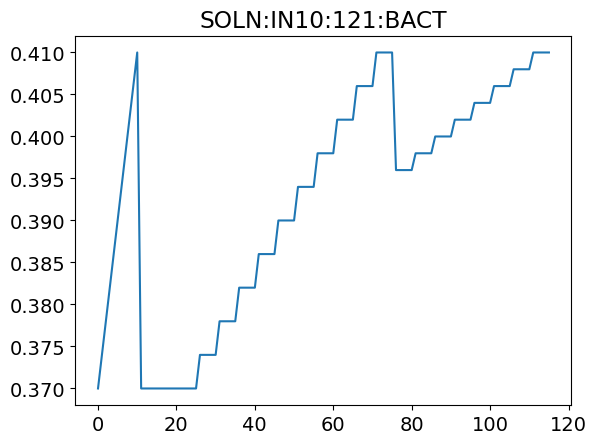

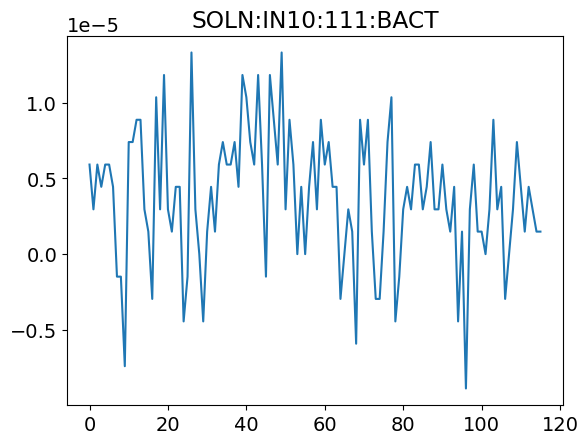

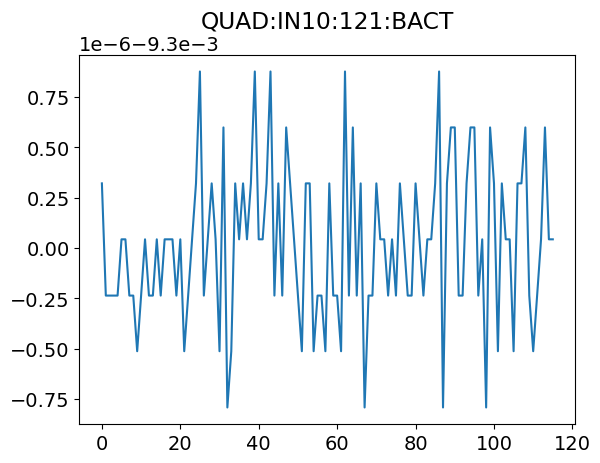

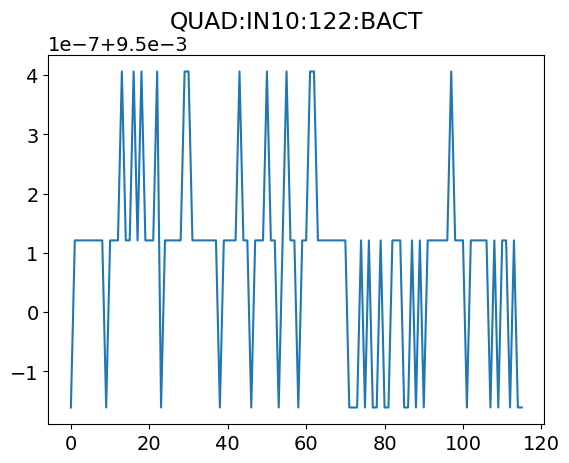

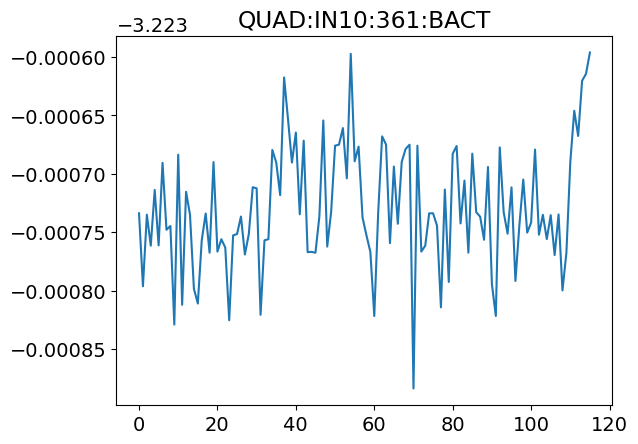

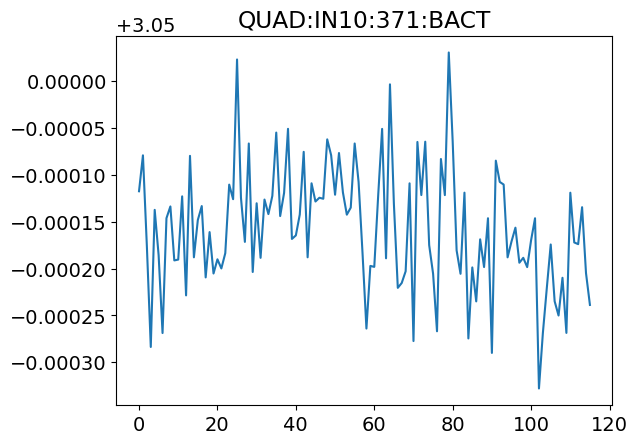

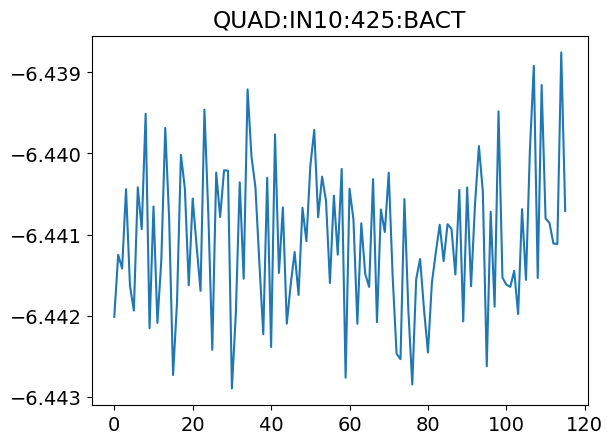

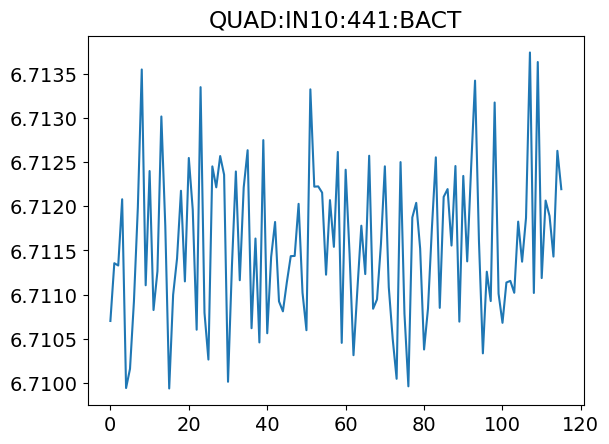

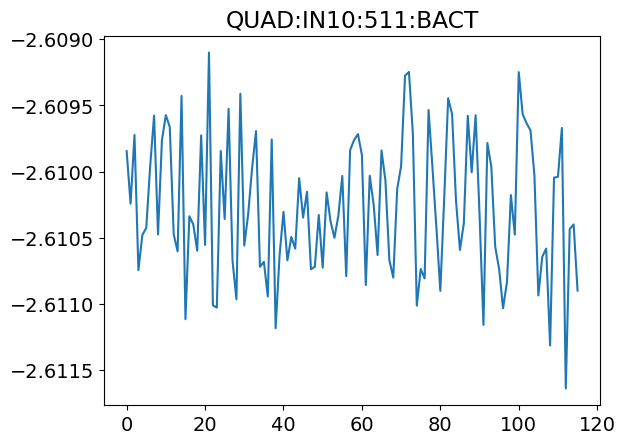

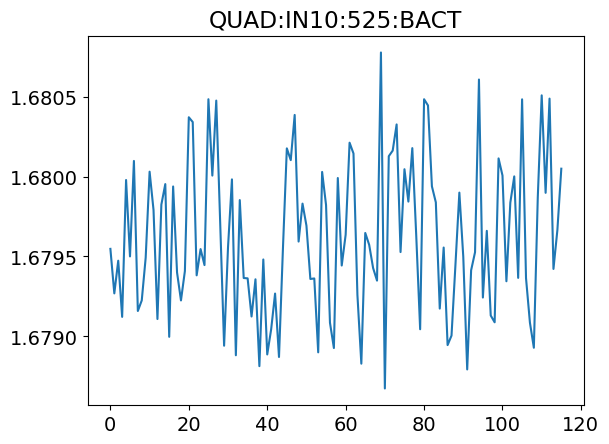

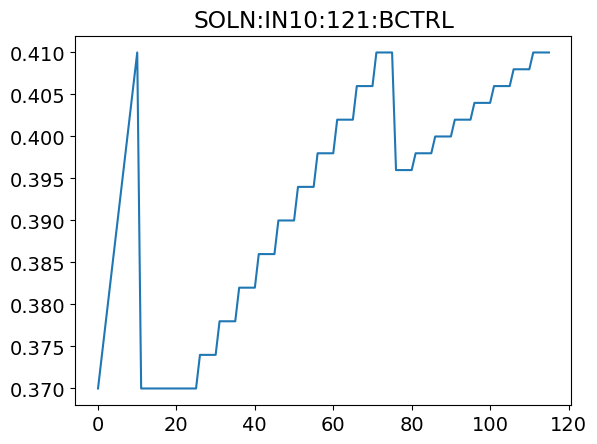

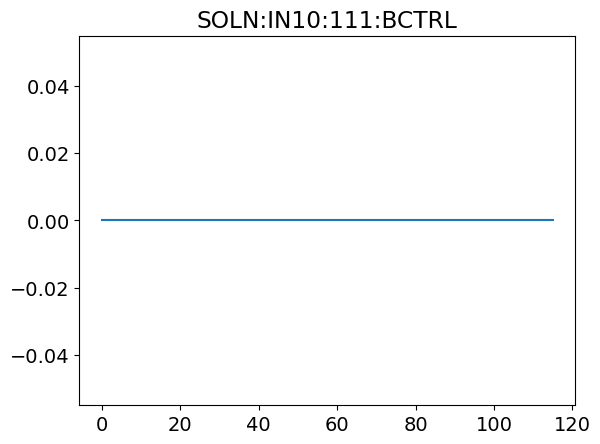

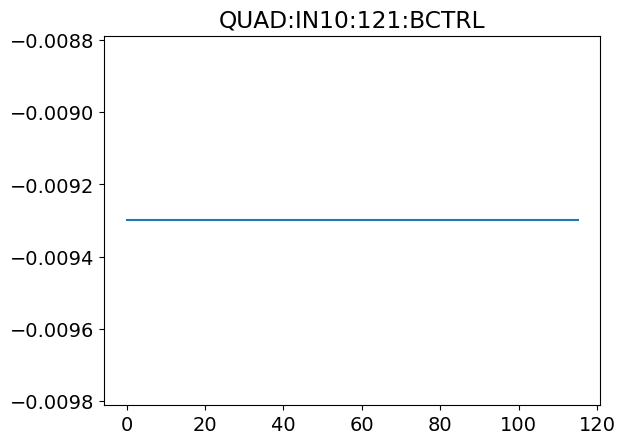

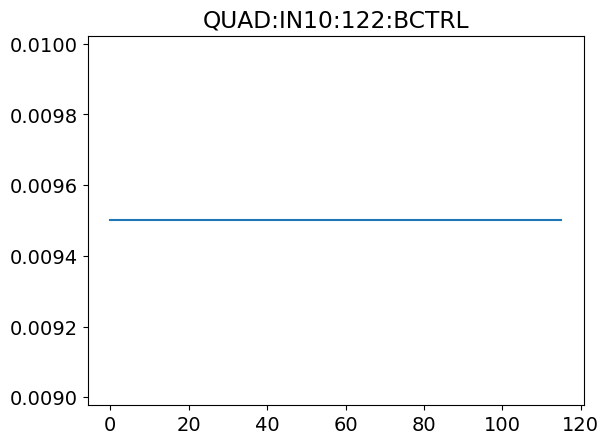

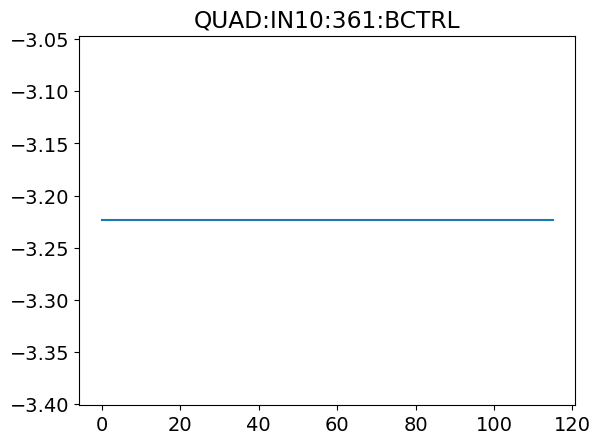

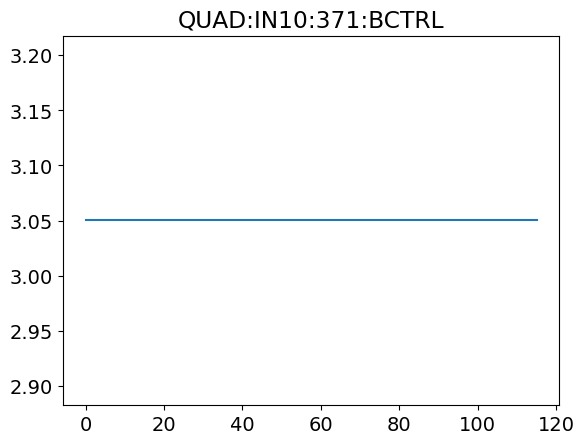

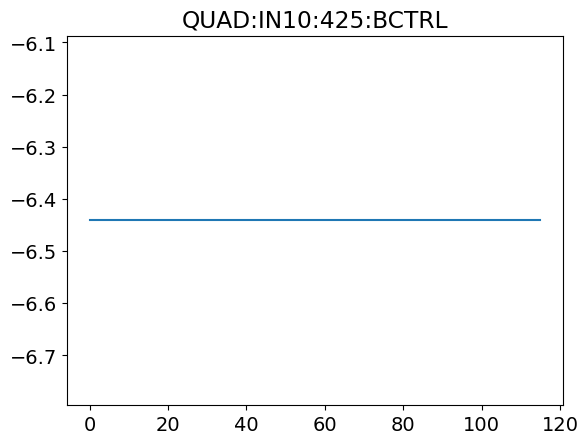

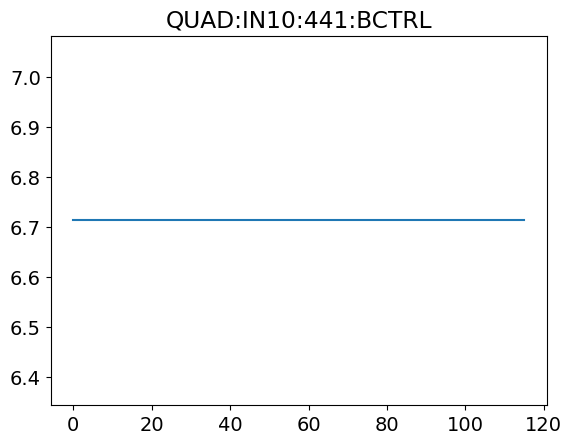

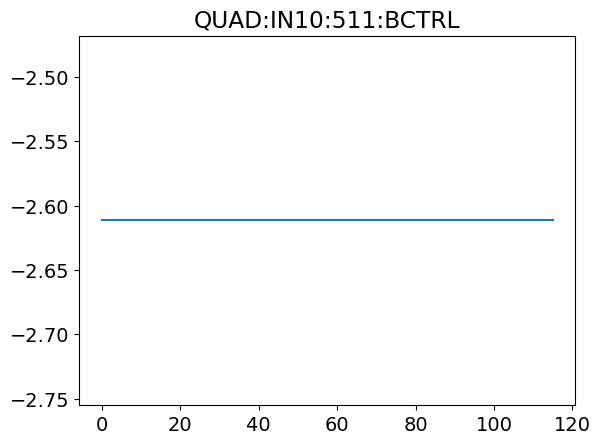

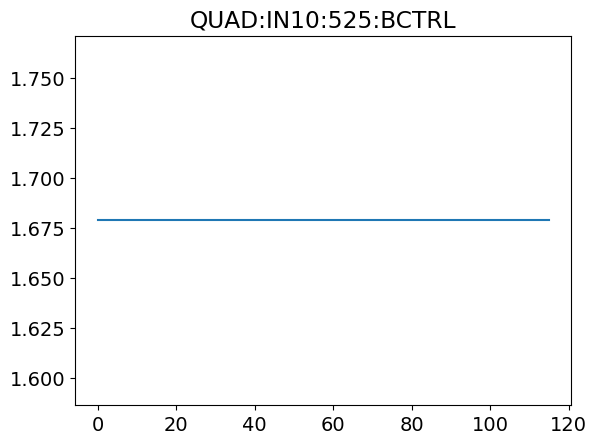

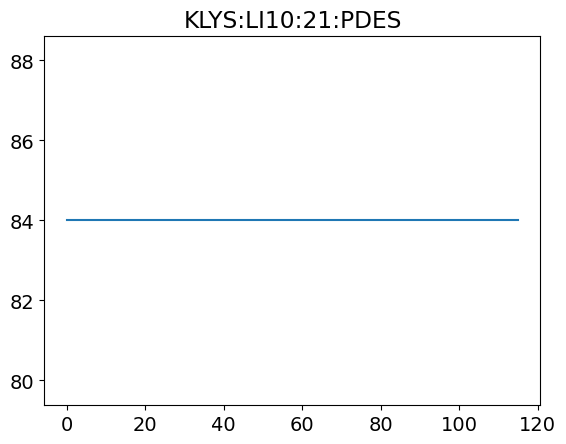

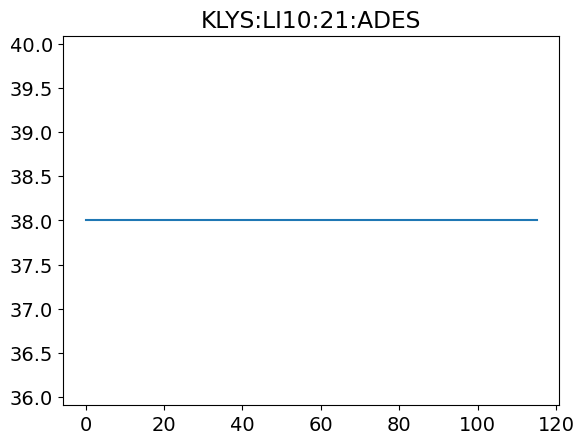

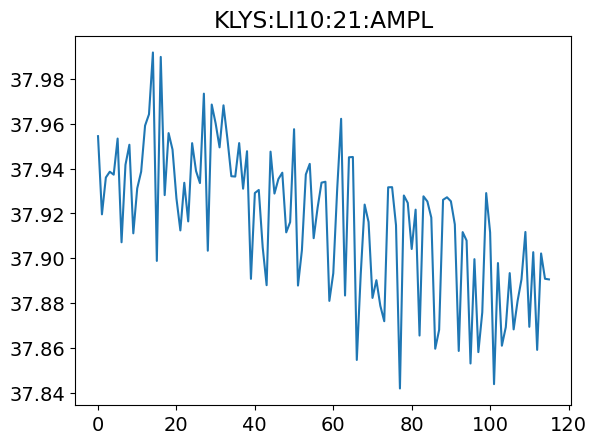

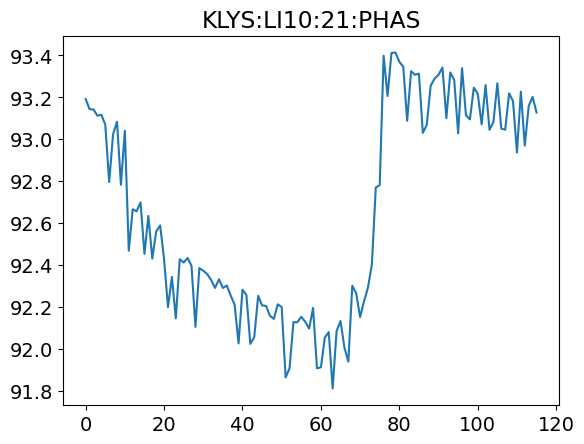

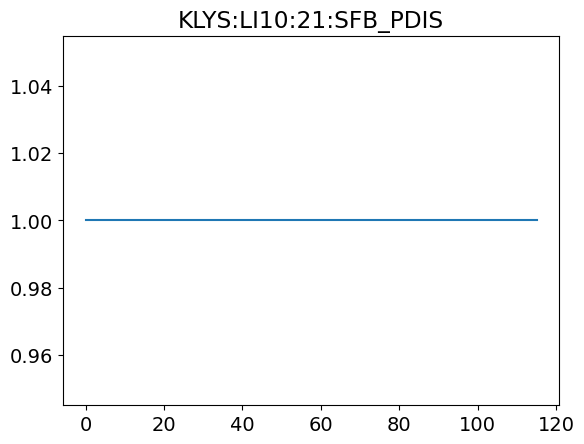

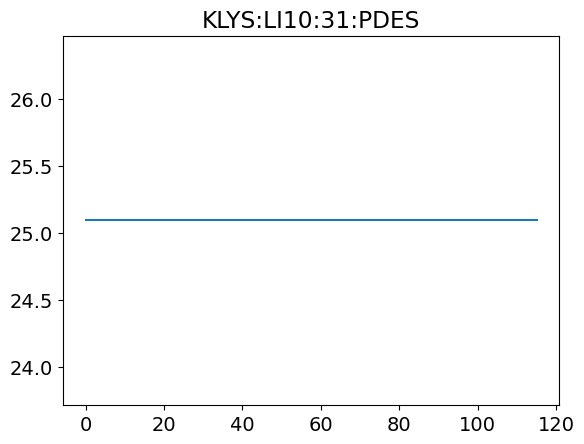

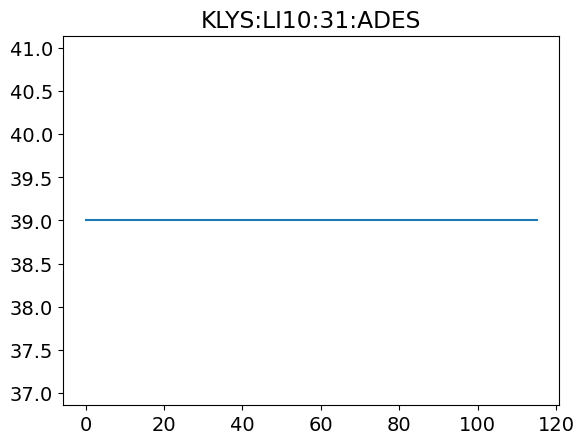

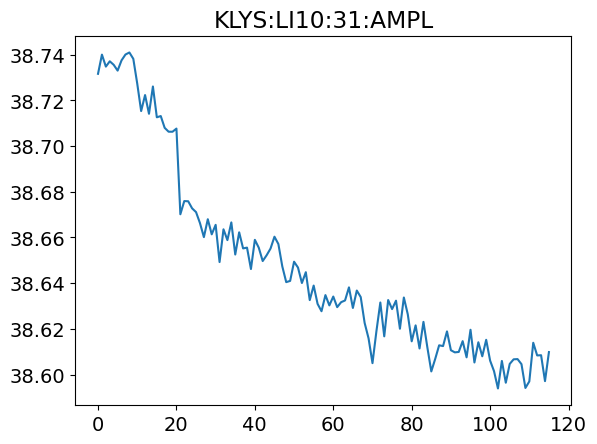

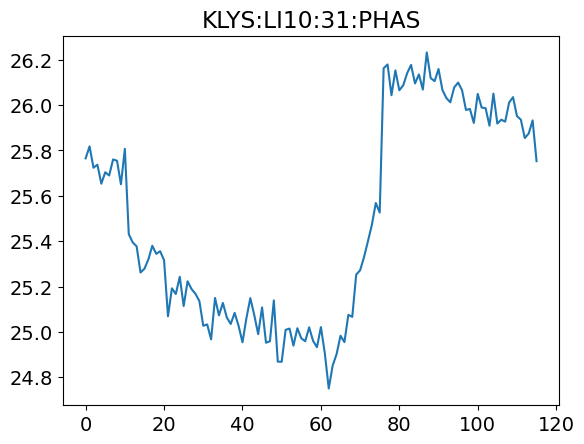

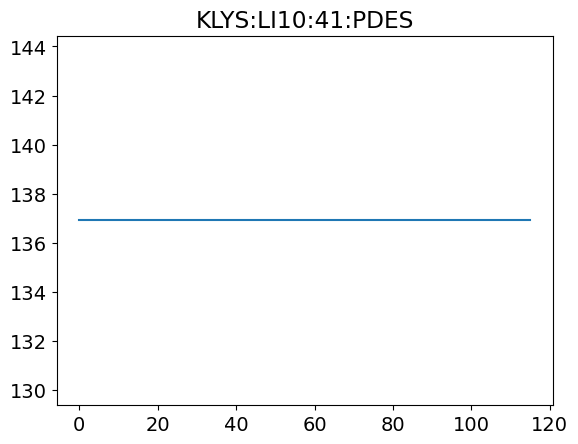

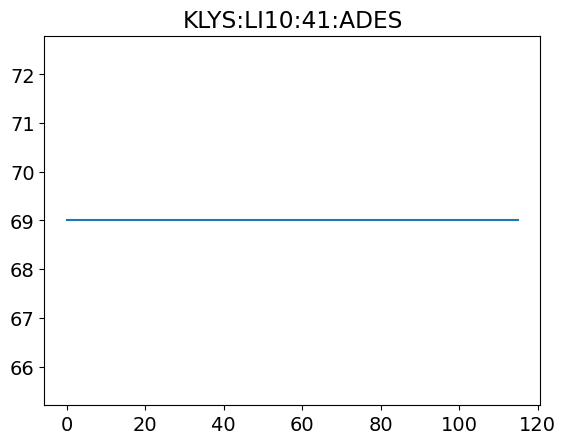

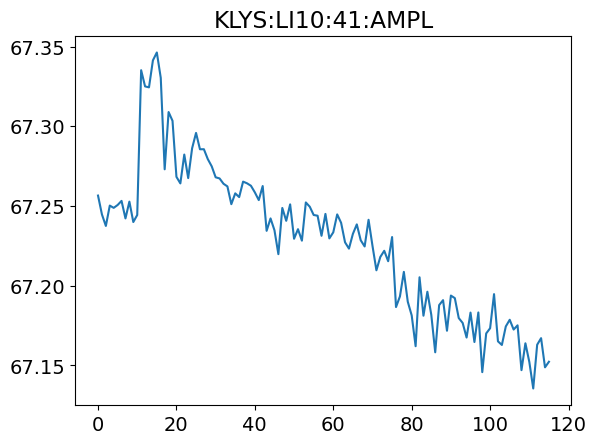

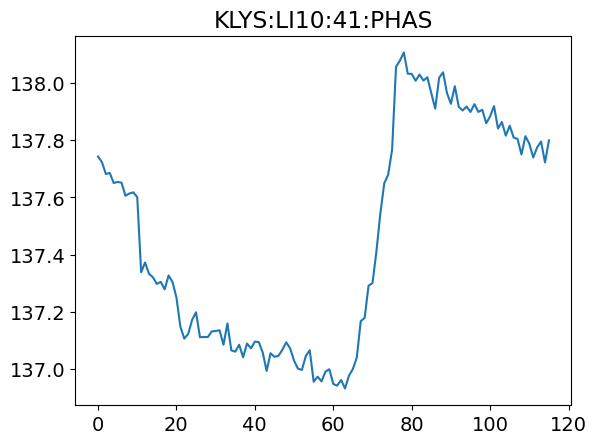

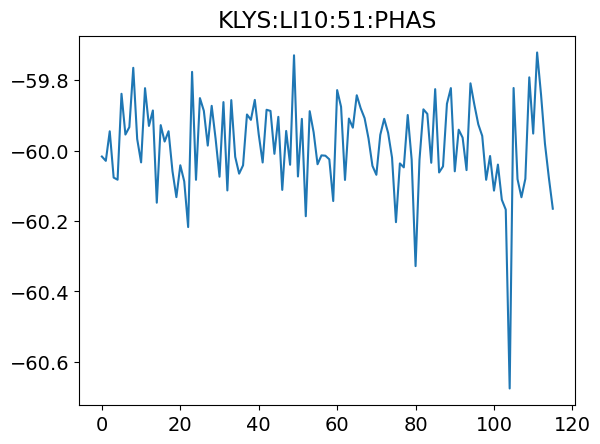

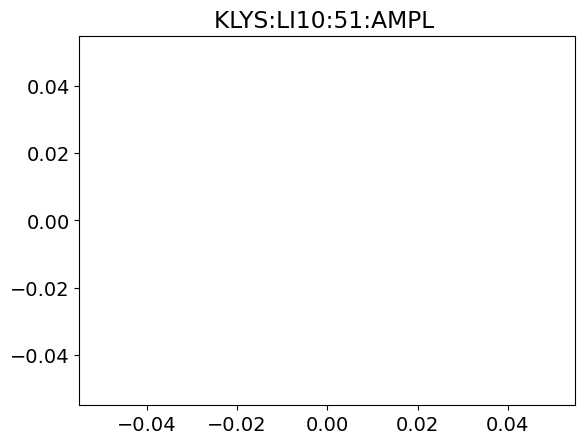

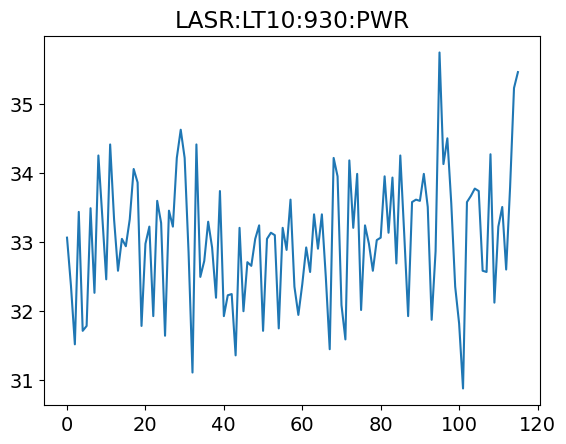

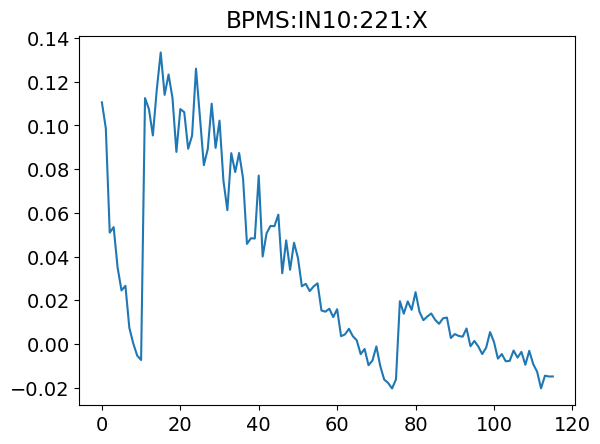

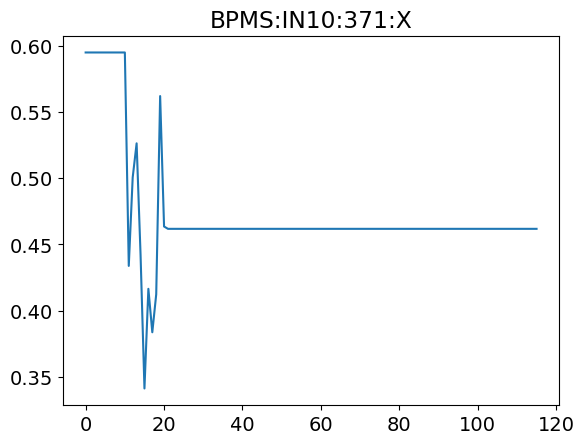

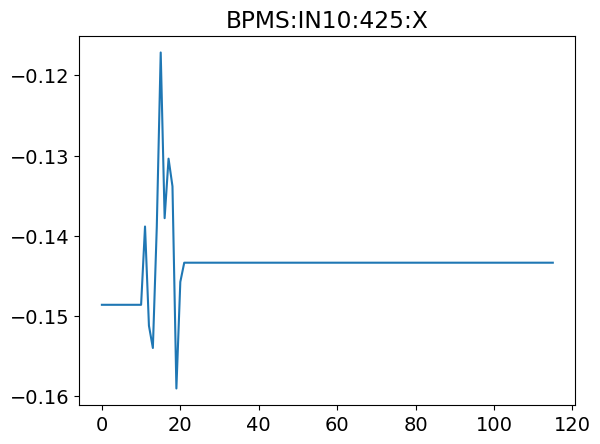

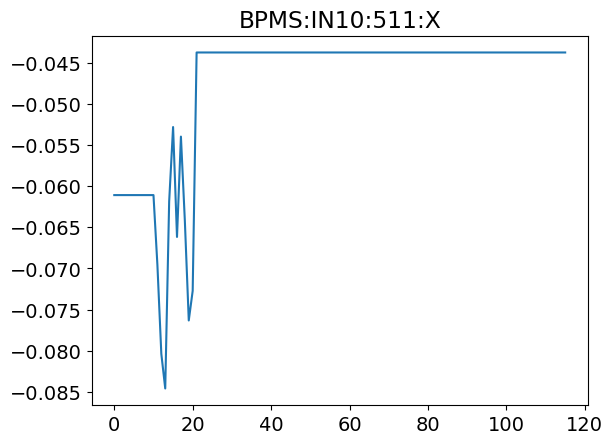

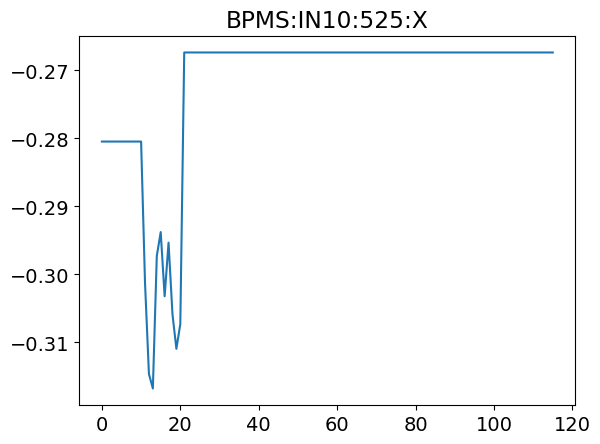

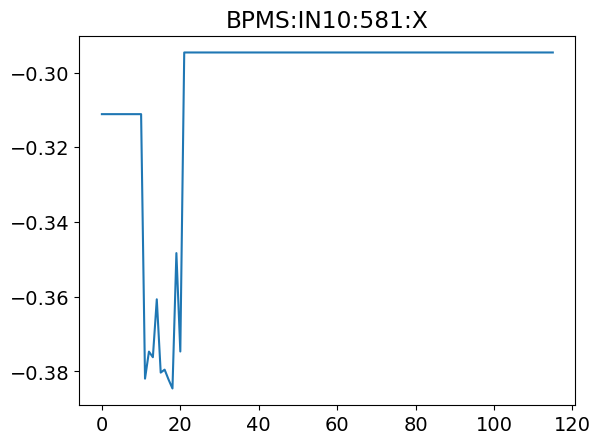

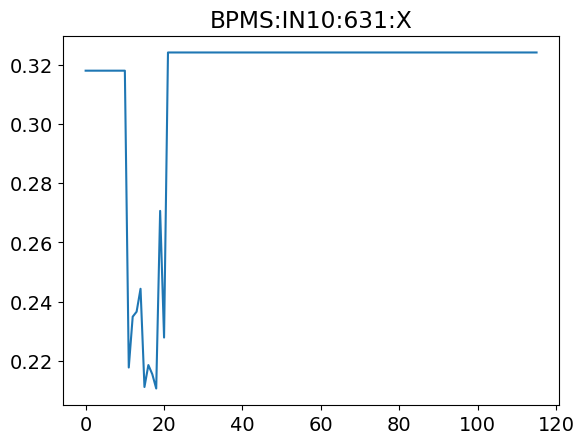

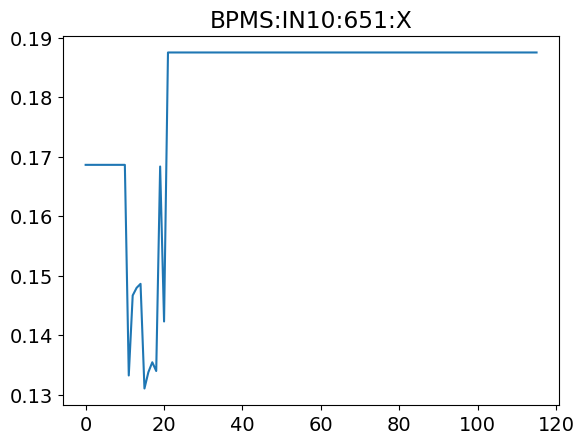

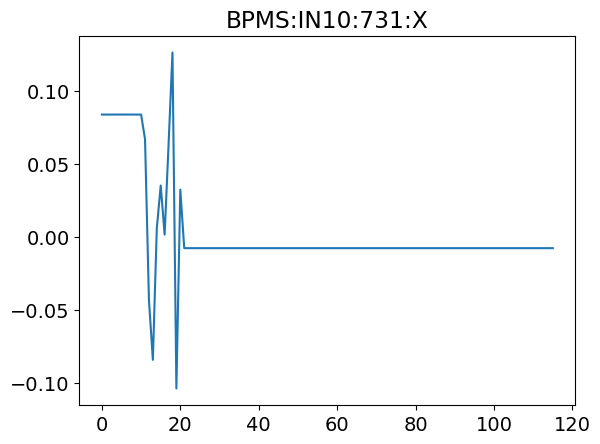

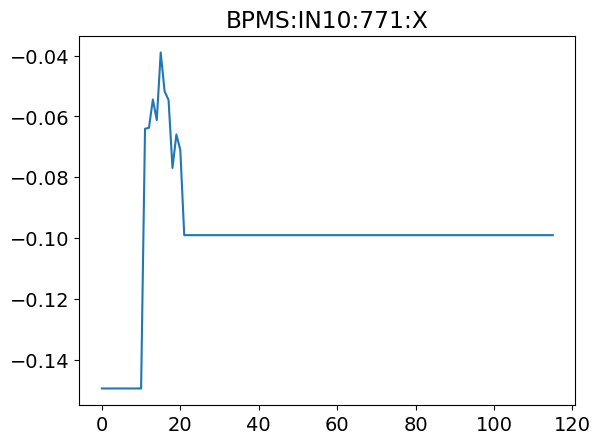

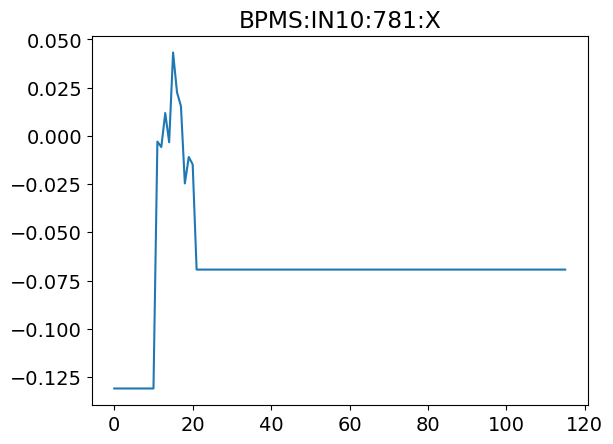

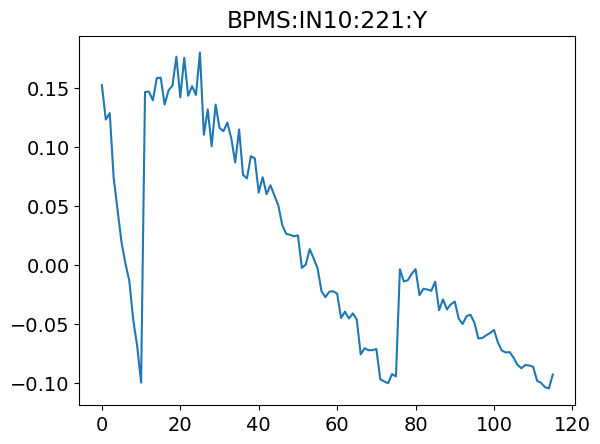

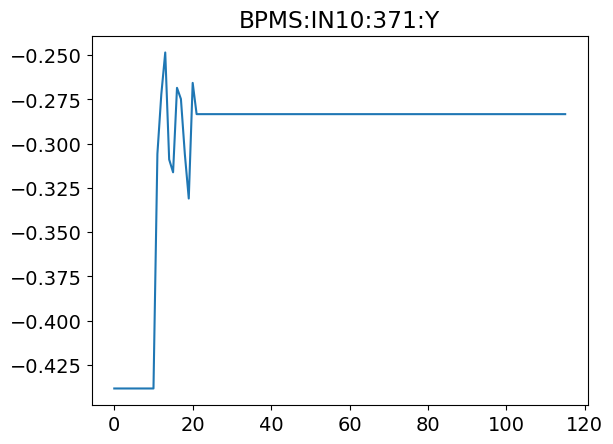

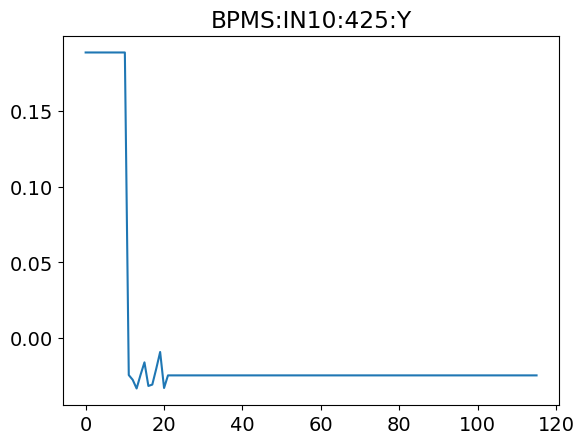

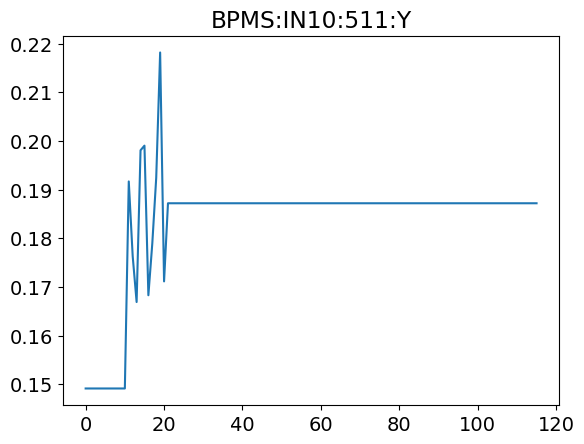

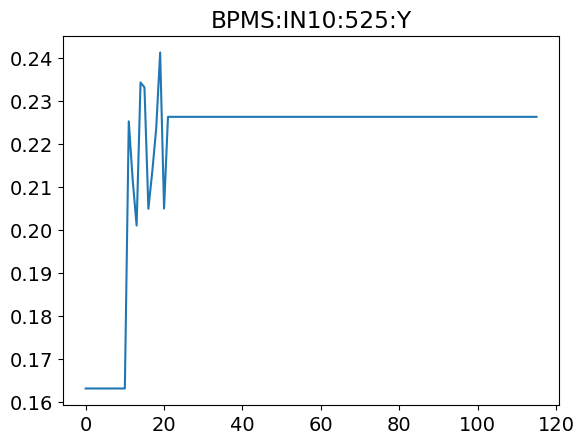

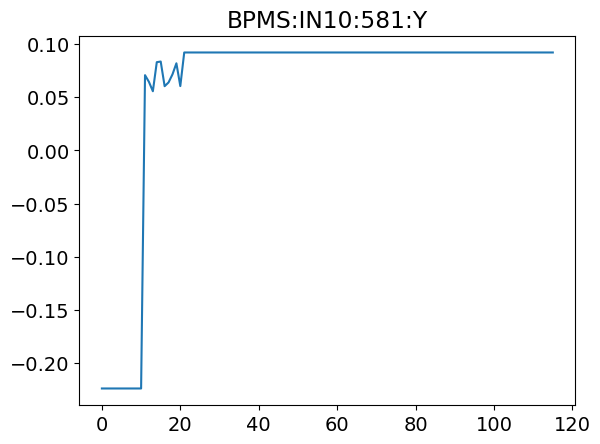

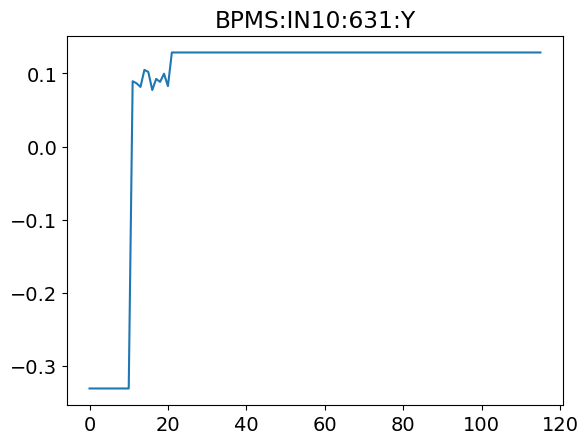

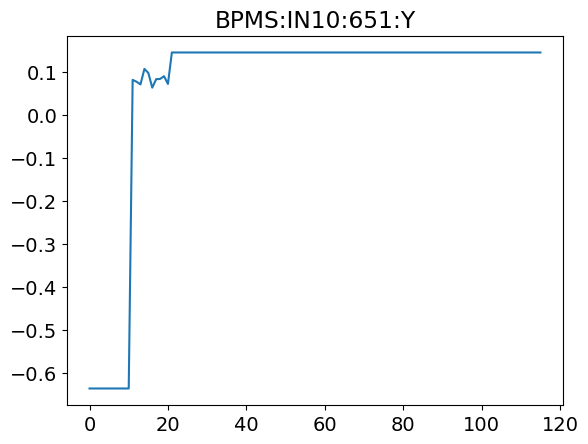

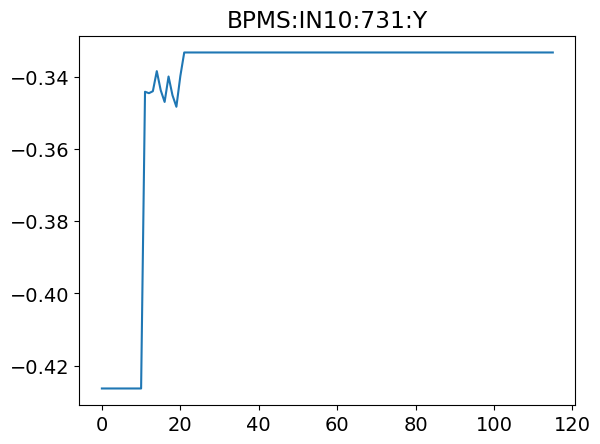

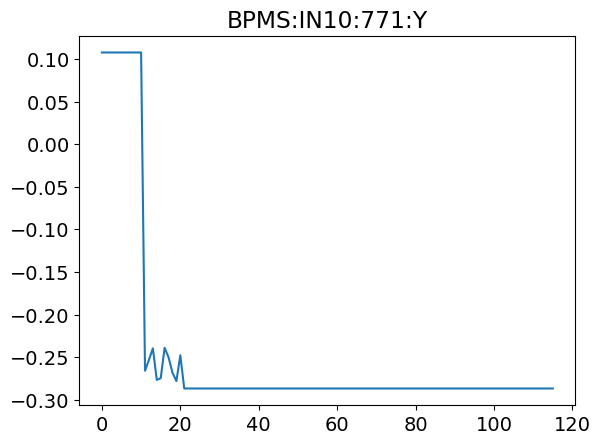

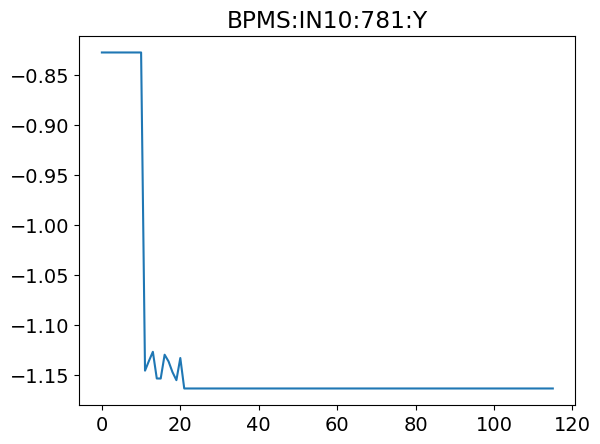

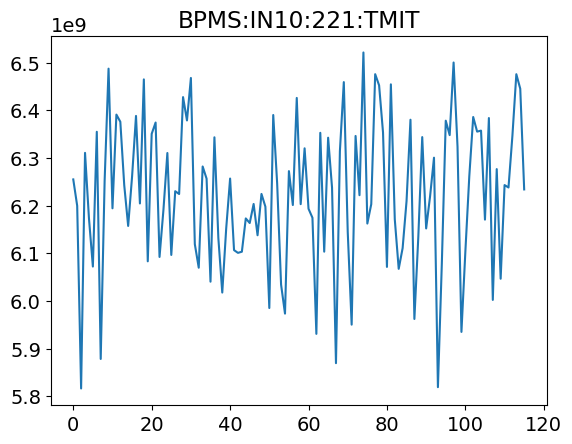

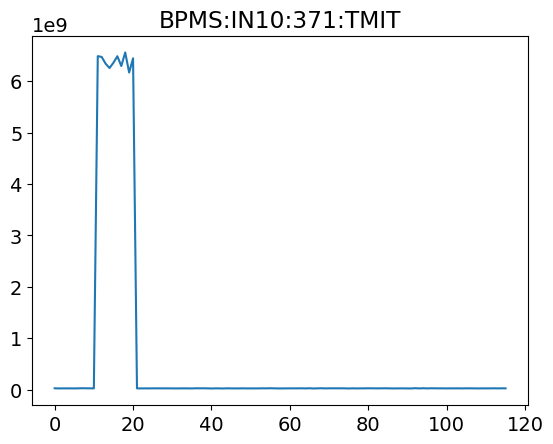

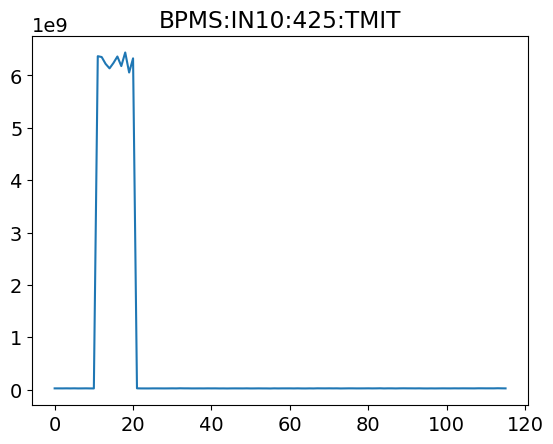

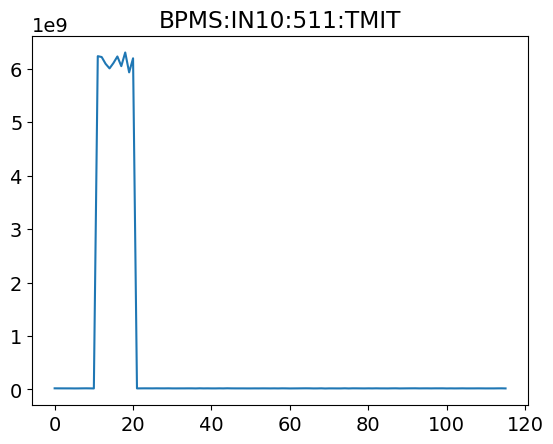

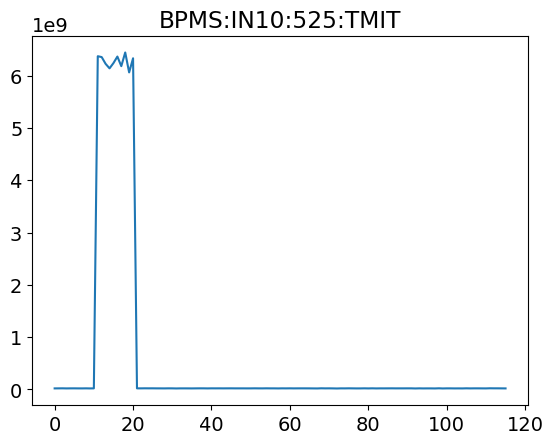

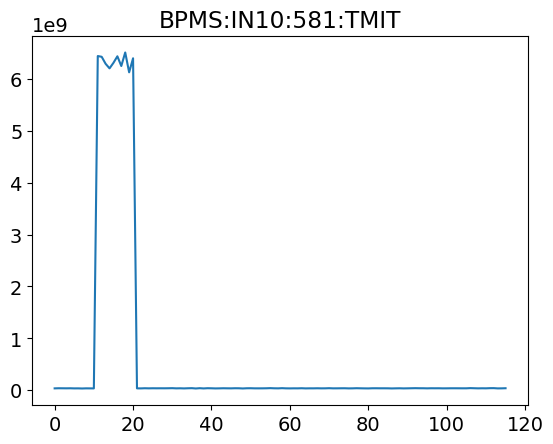

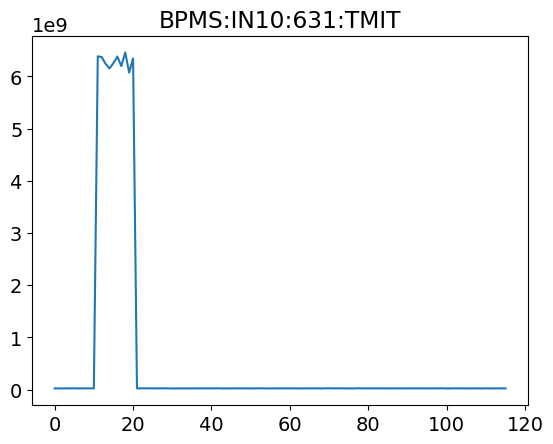

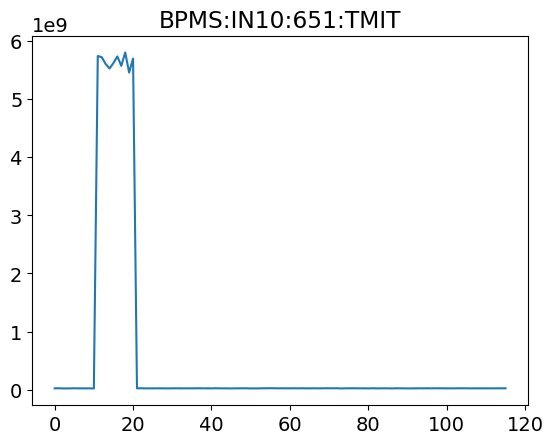

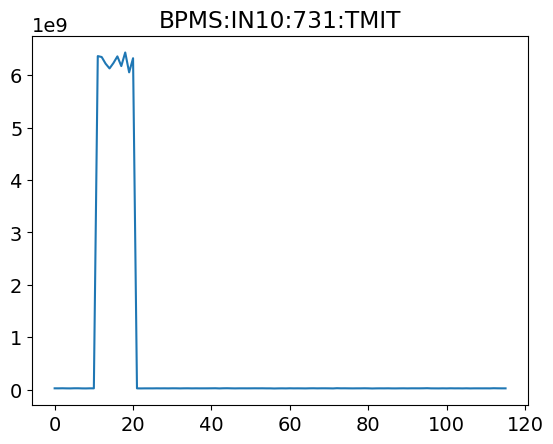

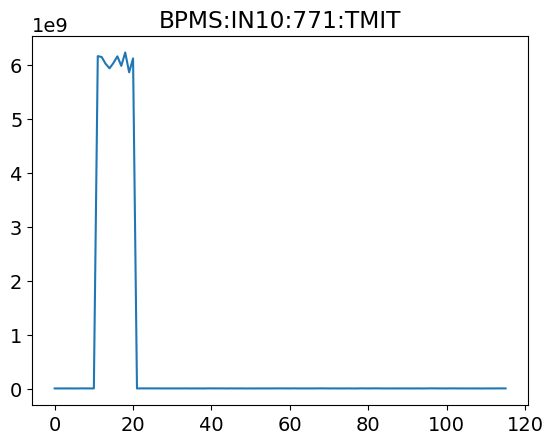

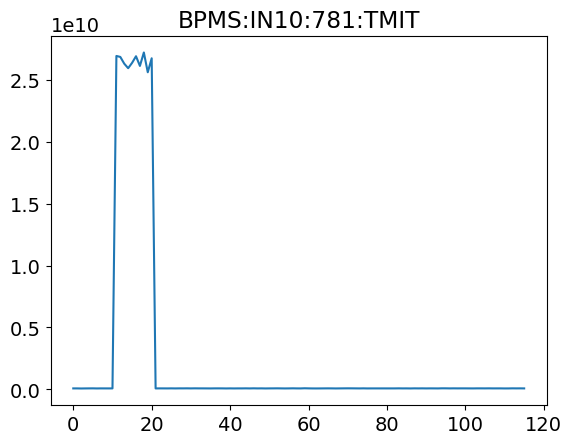

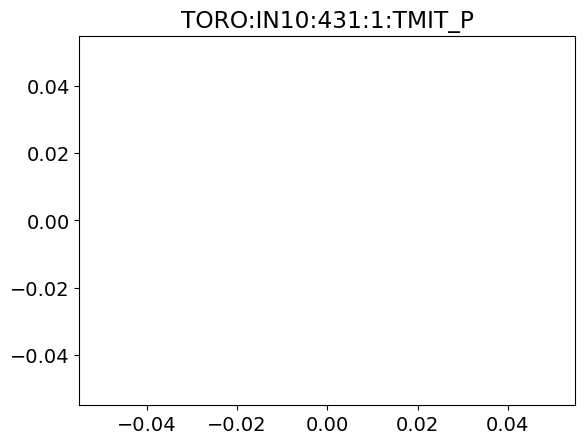

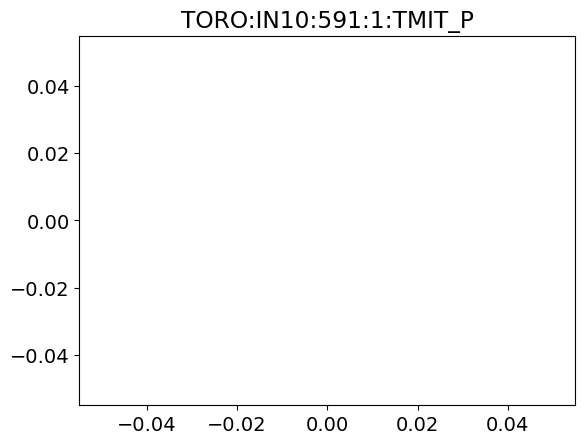

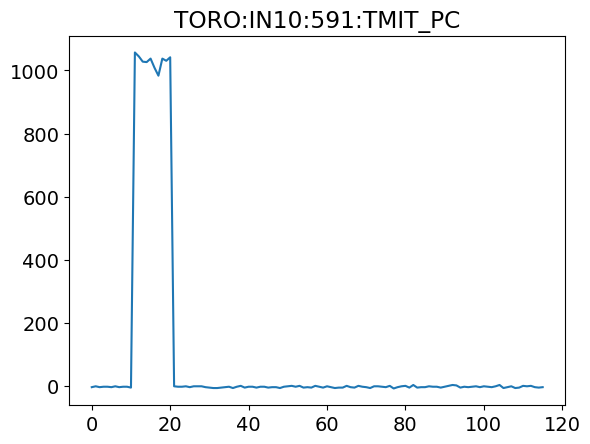

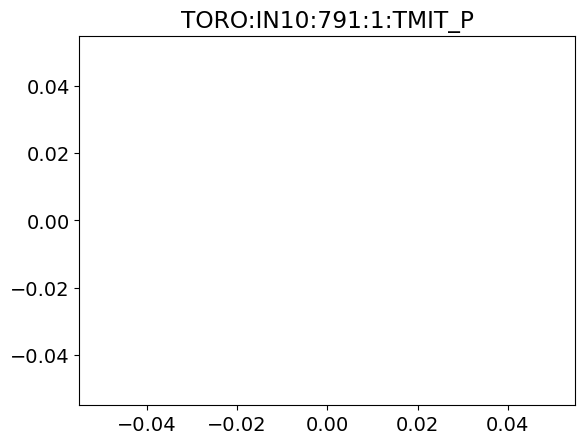

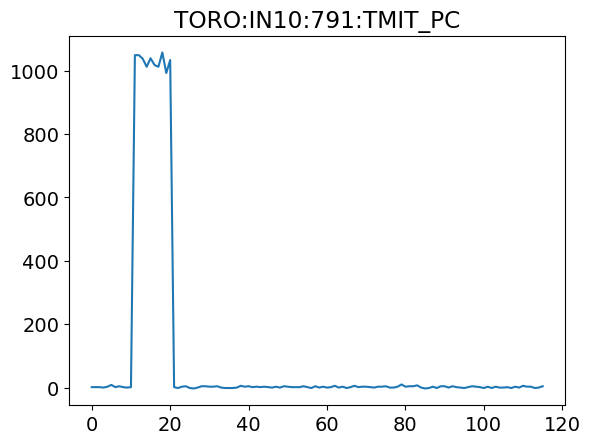

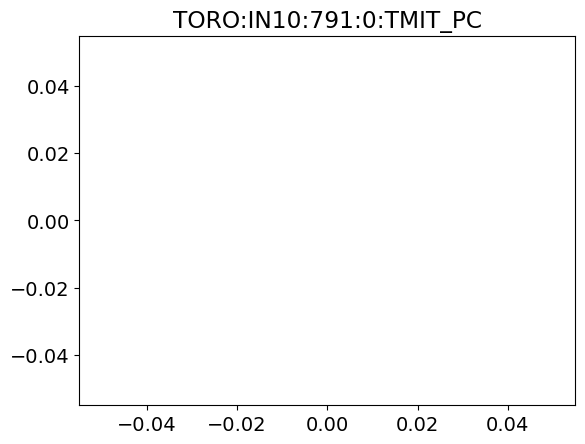

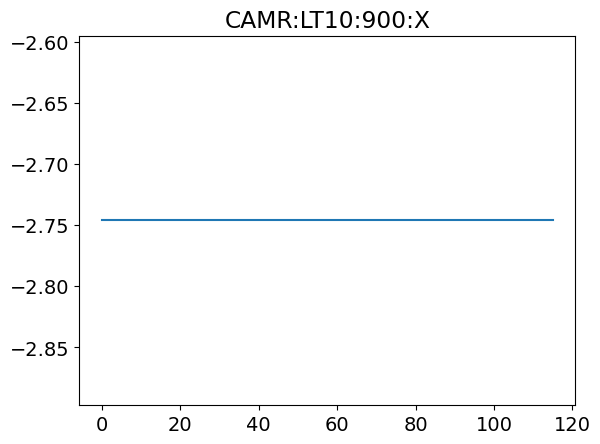

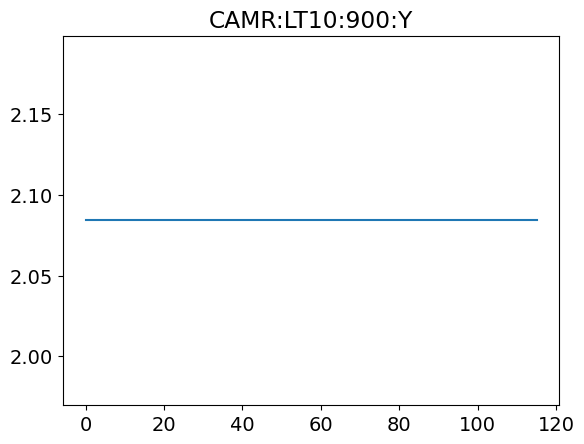

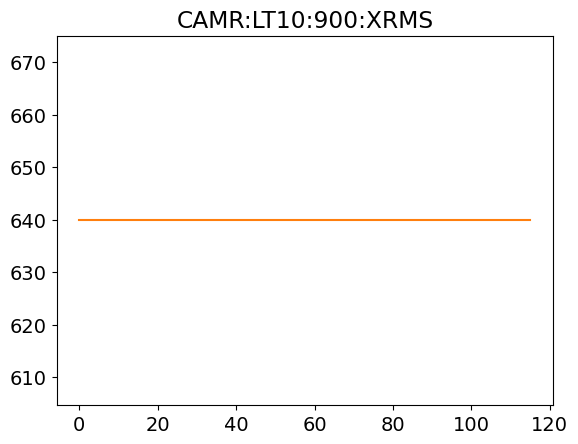

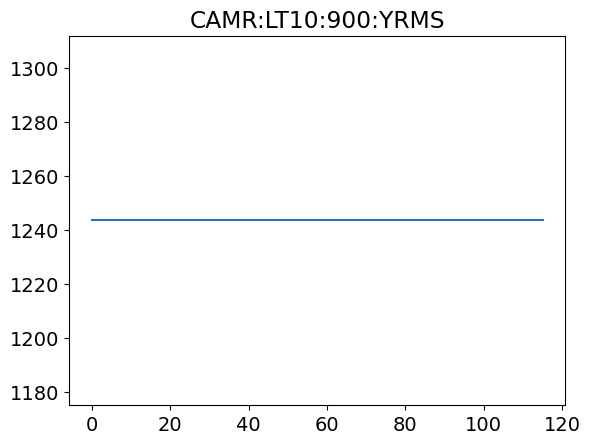

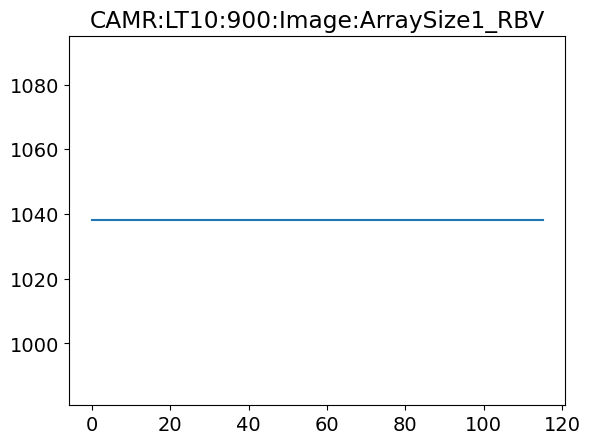

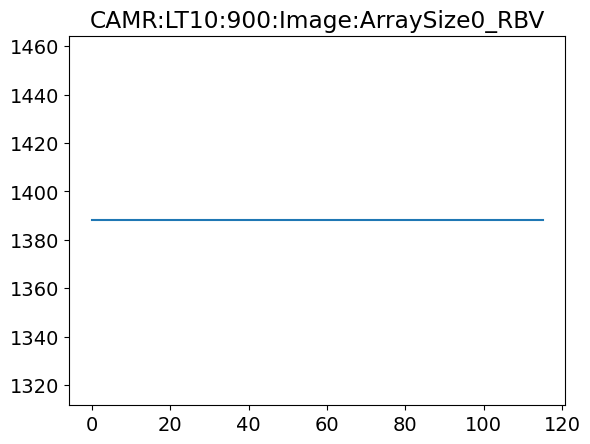

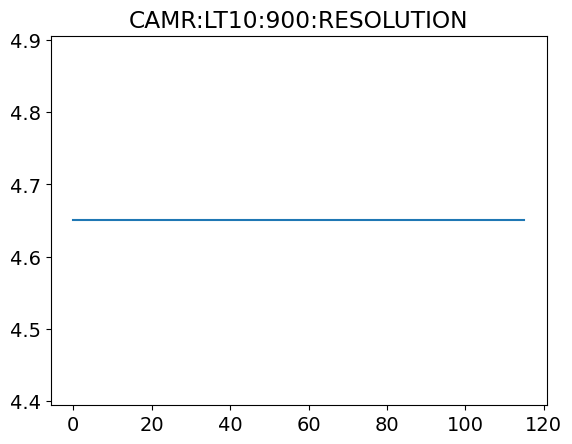

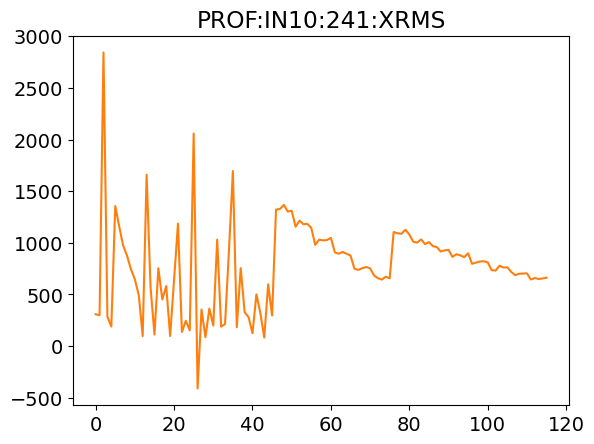

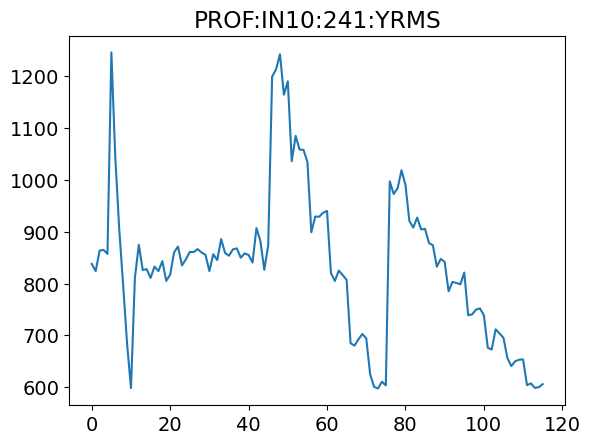

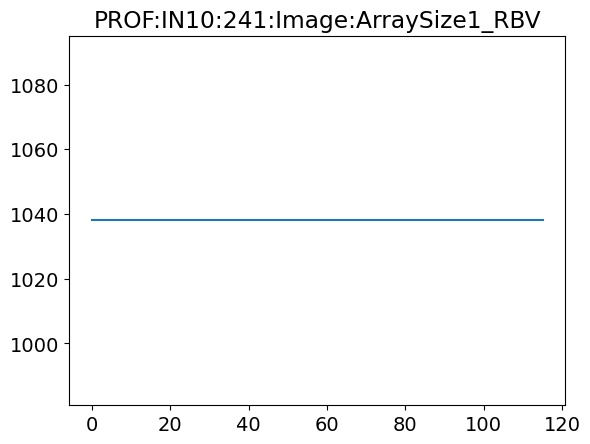

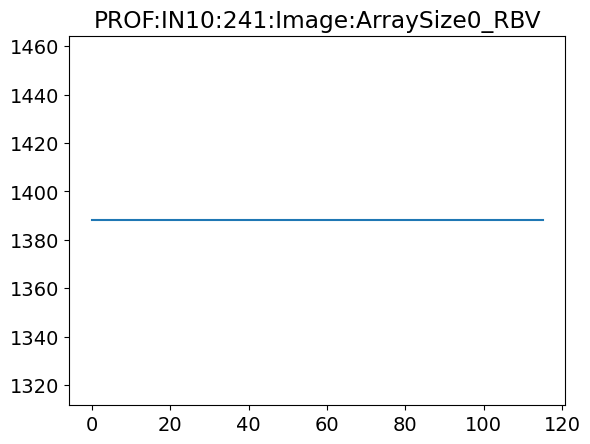

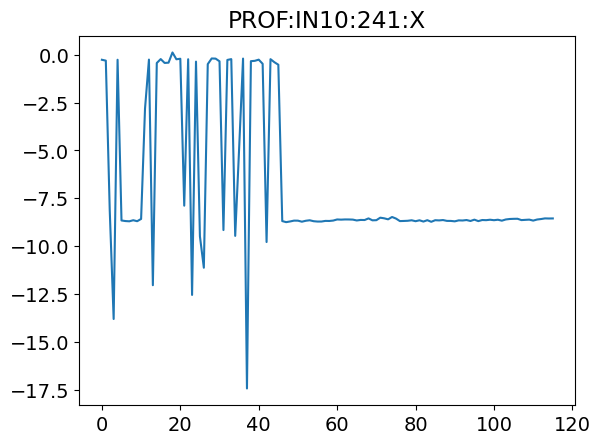

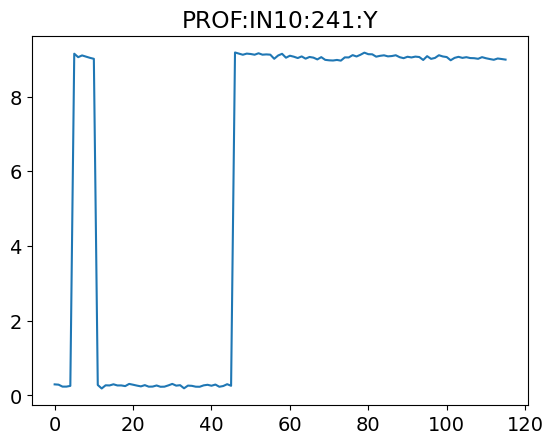

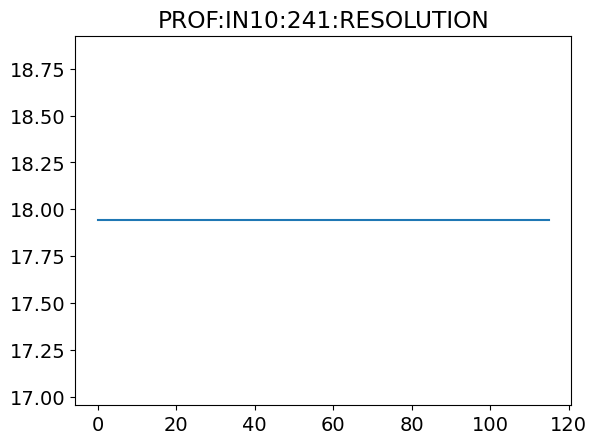

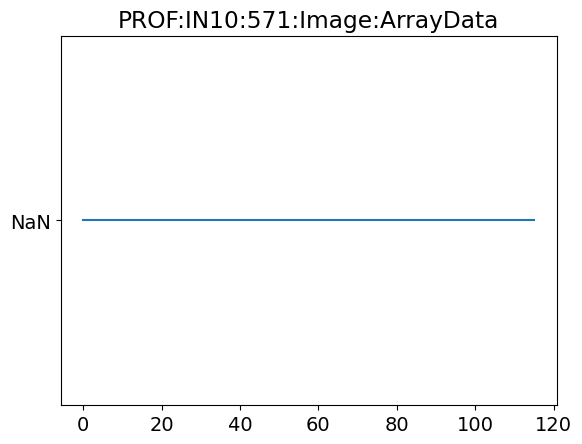

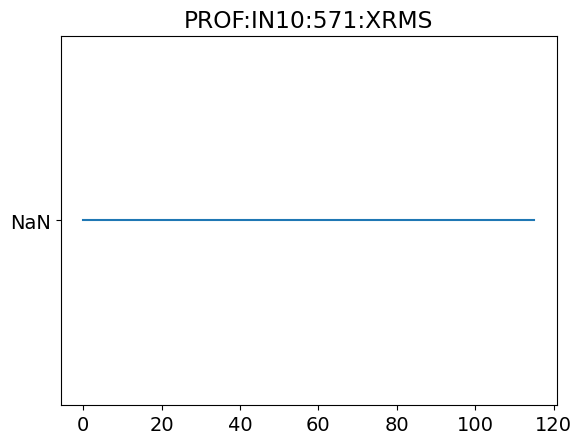

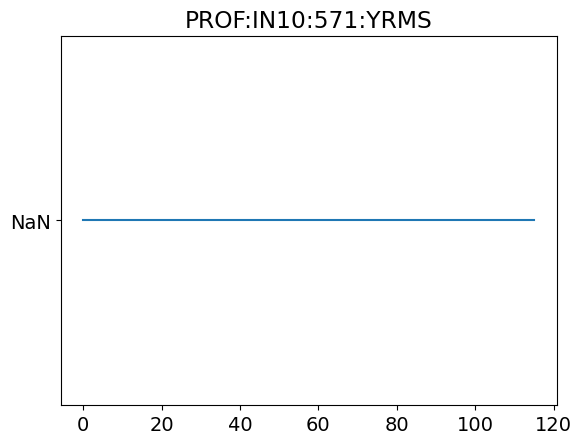

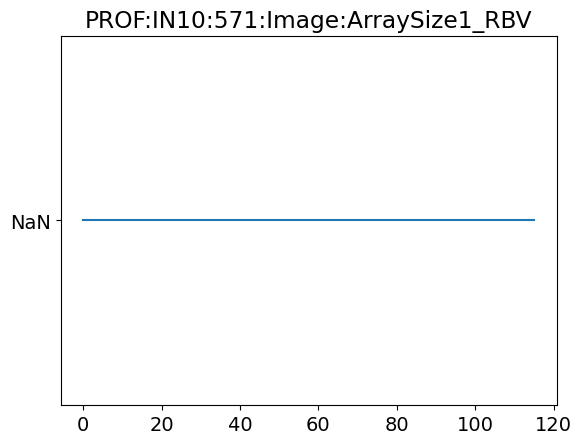

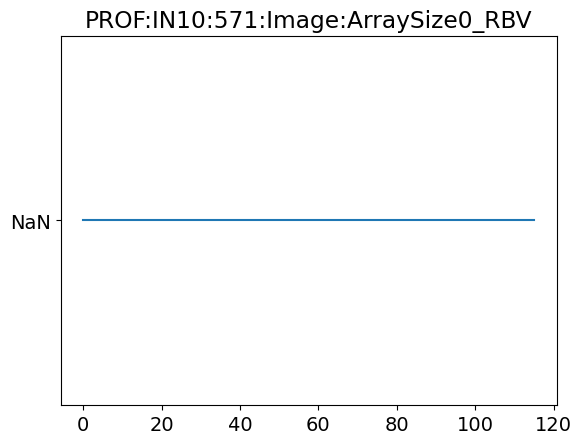

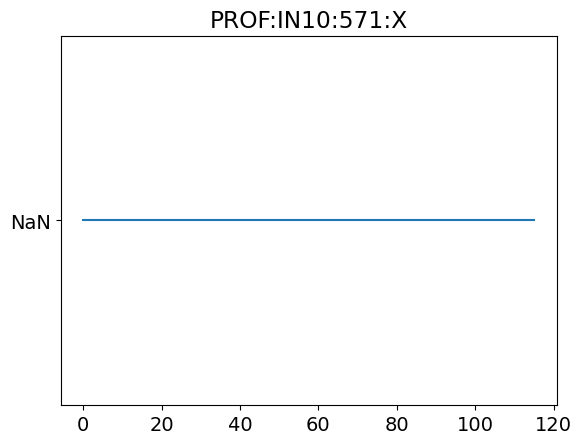

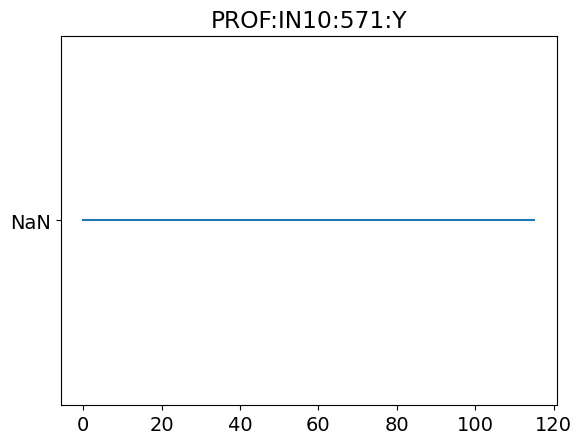

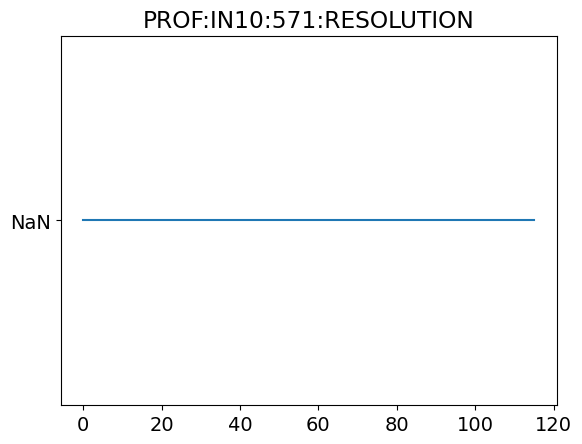

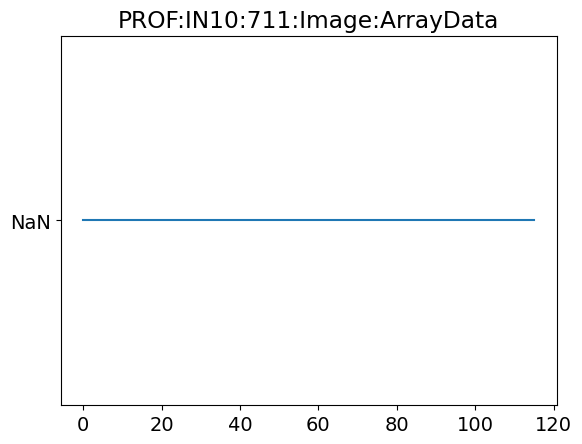

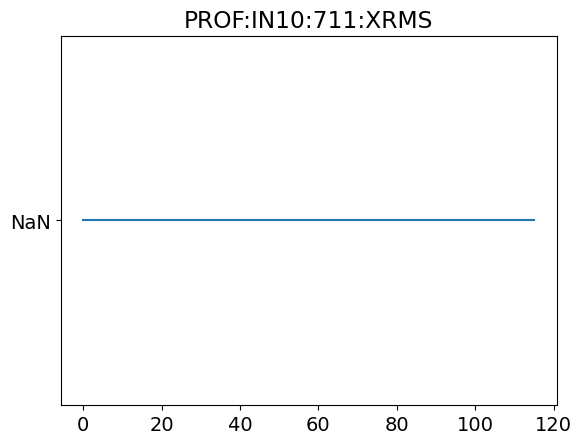

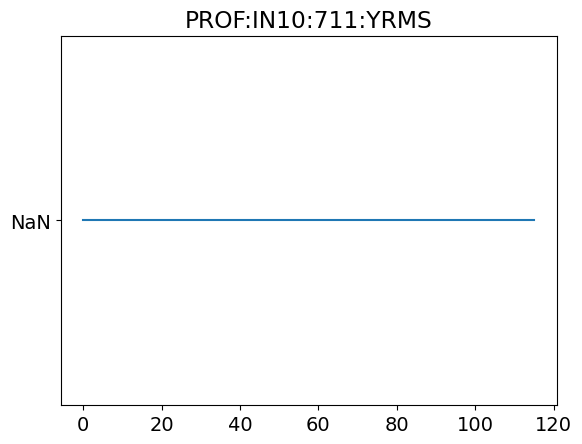

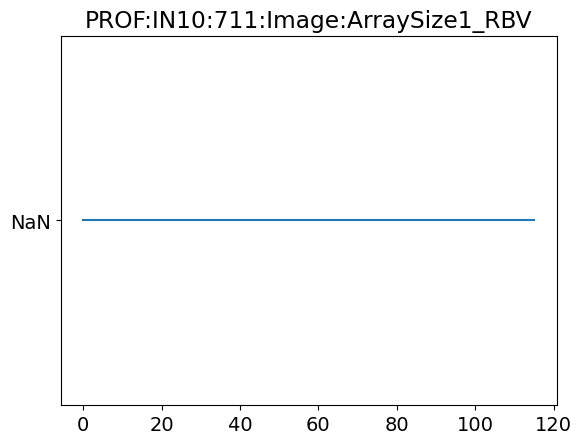

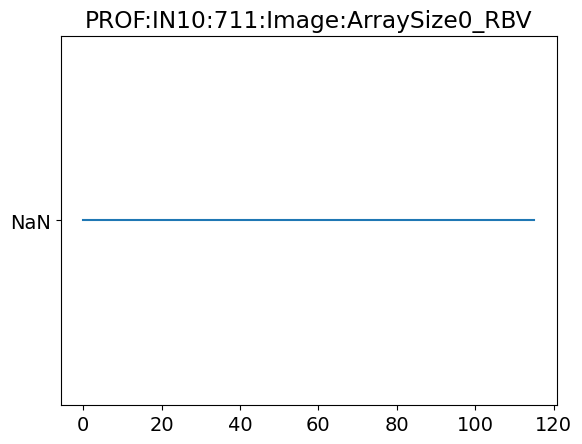

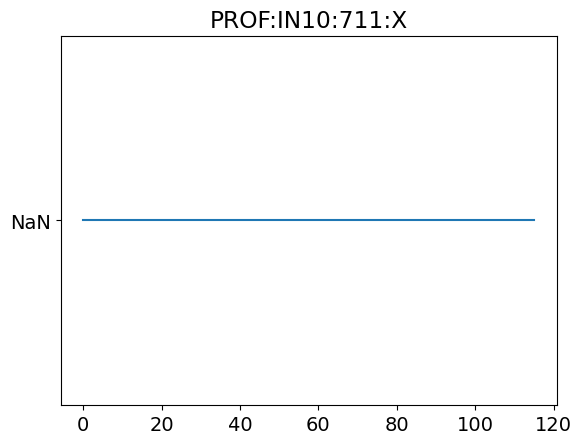

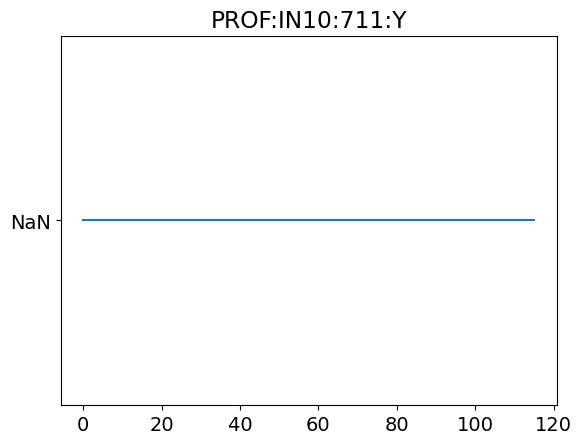

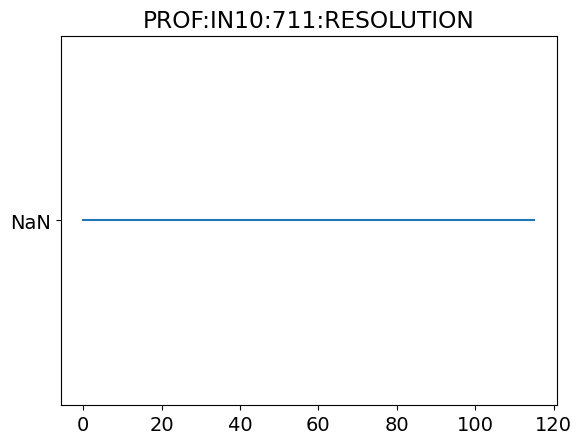

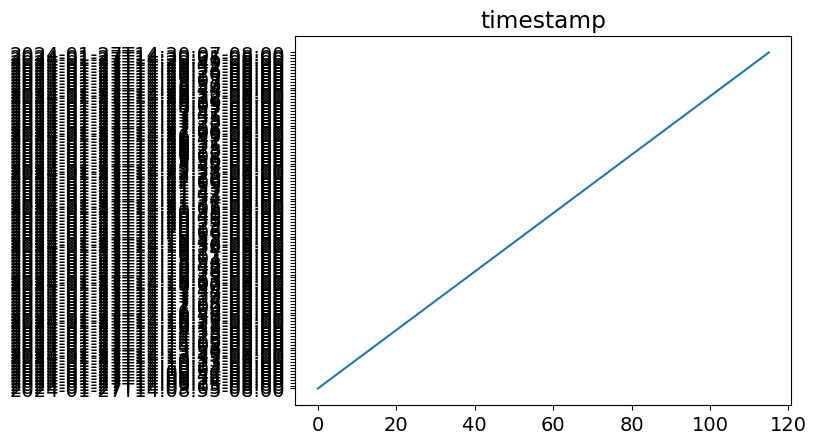

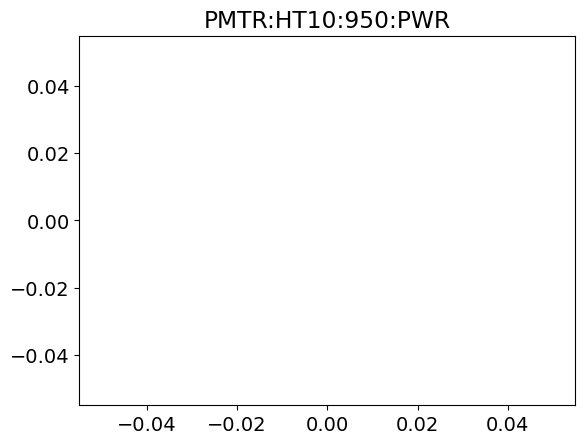

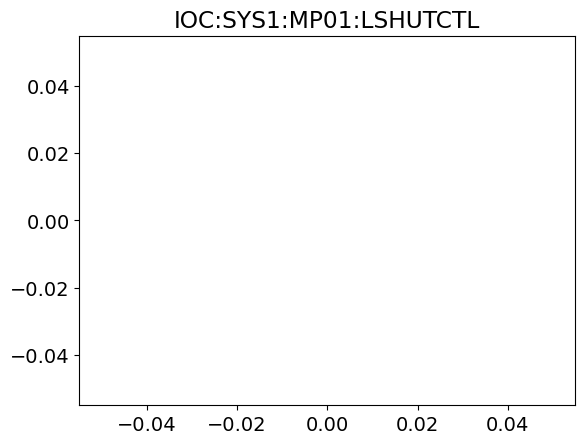

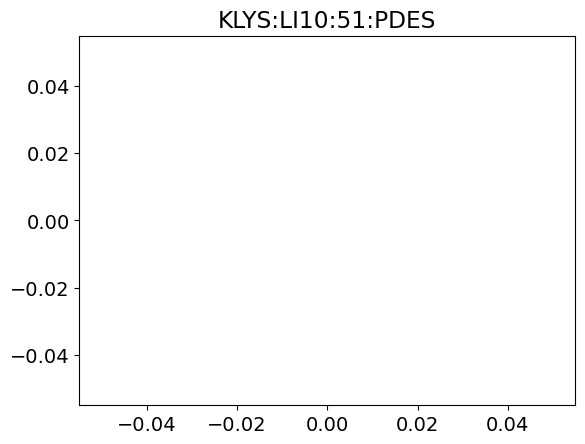

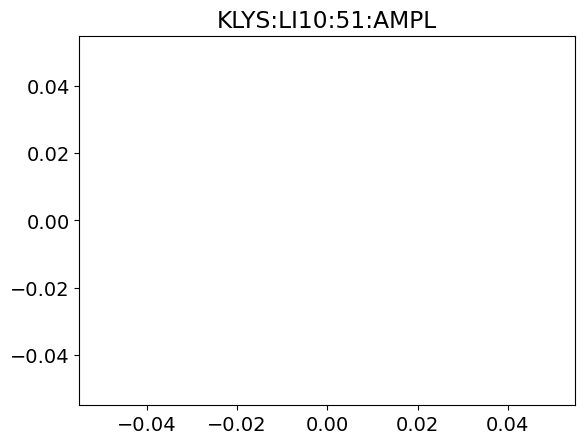

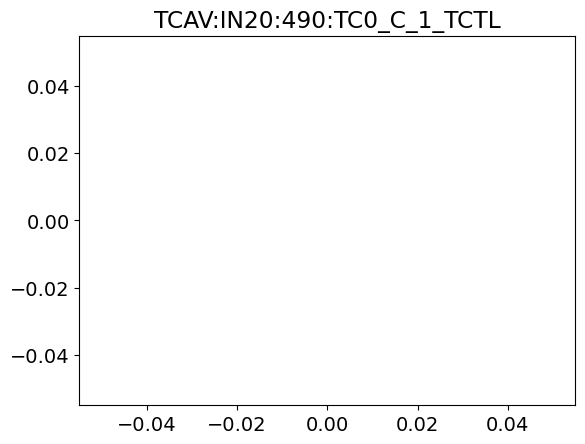

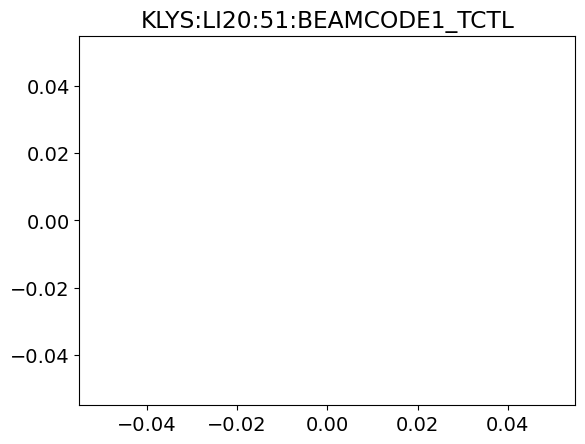

In [32]:
for i in range(len(non_sync_data_screen.columns)):
    try:
        plt.plot(non_sync_data_screen.reset_index()[non_sync_data_screen.columns[i]])
        plt.title(non_sync_data_screen.columns[i])
        plt.show()
    except:
        pass

## Save Data

In [33]:
np.mean(non_sync_data_screen['KLYS:LI10:21:AMPL'])

np.float64(37.916724829838195)

In [34]:
np.mean(non_sync_data_screen['KLYS:LI10:21:PHAS'])

np.float64(92.659783328642)

In [35]:
non_sync_data_screen.columns

Index(['SOLN:IN10:121:BACT', 'SOLN:IN10:111:BACT', 'QUAD:IN10:121:BACT',
       'QUAD:IN10:122:BACT', 'QUAD:IN10:361:BACT', 'QUAD:IN10:371:BACT',
       'QUAD:IN10:425:BACT', 'QUAD:IN10:441:BACT', 'QUAD:IN10:511:BACT',
       'QUAD:IN10:525:BACT',
       ...
       'PROF:IN10:711:X', 'PROF:IN10:711:Y', 'PROF:IN10:711:RESOLUTION',
       'timestamp', 'PMTR:HT10:950:PWR', 'IOC:SYS1:MP01:LSHUTCTL',
       'KLYS:LI10:51:PDES', 'KLYS:LI10:51:AMPL', 'TCAV:IN20:490:TC0_C_1_TCTL',
       'KLYS:LI20:51:BEAMCODE1_TCTL'],
      dtype='object', length=114)

In [36]:
if '2024-03-' in save_loc and screen_nickname=='241':
    len(charges)
    non_sync_data_screen['manual_charge'] = charges

In [37]:
non_sync_data_screen.to_pickle(save_loc + 'non_sync_data_' + screen_nickname + '.pkl')